GPU on DAP:
* pip install numba-cuda[cu12]

Since one can't install ipykernel in .venv, you need to install the folder as a package on ```(virtual-env)```
On DAP:
* do `unzip -o graph-ensemble.zip` 
If not working, remove `mc rm -rf graph-ensemble` and, then, `unzip graph-ensembles.zip`;
* `deactivate` (the `virtual-env`) such that the standard jupter kernel is selected;
* install via `pip install --editable . --config-settings editable_mode=compat`
* create a cell down here and do `import graph_ensembles` to check the installation;

Commands
* For this proj, ```vars``` and ```plots``` are saved in `./outputs`, but in the old version in
```/home/inghero/data/corealgos/rmilocco/outputs/datasets/ING-Directed```
* Delete folders on dap: ```mc rm --force --purge folder```
* To save new plots, delete previous ones with
```mc rm --force --purge dap/corealgos/rmilocco/outputs/datasets/ING-Directed```

On local:
* Linux: Zip outside the ``graph-ensembles`` folder: 
<br>```zip -rX graph-ensembles.zip graph-ensembles -x "graph-ensembles/src/graph_ensembles.egg-info/*" ".*" "*/.*" "*/__pycache__/*" "*/sythetic_network/*"```

Run the right install cmd from [pytorch](https://pytorch.org/), based on your architecture

Claim: by reconstructing the unobserved, we may close the gap between the total Page-Rank and Page-Rank only inside the ING-clients

1) Split the nodes into ING (`vI`) and `ROW` (`vR`);

2) Find ``vI`` and ``eI`` as the edges only between. We will cal `intra` (`eI`) edges, `bet` (ING-ROW), `row` (non ING interacting clients); 

4) Calculate the Page-Rank of only the `intra` nodes and compare it with the full graph PR.
Now, we expect that the 2 PR are different. So, help this bias by reconstructing the missing part;

5) Calculate the strengths taking into account also the ING-ROW fluxes, while discarding the self-payments;
6) Freeze the `eI` and fit $\delta$ parameter as 
    * $L_I \stackrel{!}{=} \langle L_I \rangle(\delta_I) := \sum_{i \in I, j \in I} p_{ij}(\delta_I)$;

    * $L^{no-I}_U = L_I + L_{bet} \stackrel{!}{=} L_I + \sum_{i \in I, r \in R} (p_{ir}(\delta_{U}) + p_{ri}(\delta_{U})) $;

    * $L_U = L_I + L_{bet} \stackrel{!}{=} \sum_{(i,j) \in \left\{(I,I),(I,R),(R,I) \right\} } p_{ij}(\delta_{U}) $;

7) Page-Rank (or Influence Vector);

In [1]:
# auto-reload the packages at every run
%load_ext autoreload
%autoreload 2

#display all the results not only the last one
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

try:
    corpkey = True if os.environ['DSBOX_USERNAME'] else None
    %pip install matplotlib pandas scipy numba fast_pagerank tqdm
    %pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
except:
    corpkey = None

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch as tc
import os
import graph_ensembles as ge
from graph_ensembles import sparse as sp
import graph_ensembles.utils as utils
import graph_ensembles.dependencies as dep
from graph_ensembles.plots import plotting_functions as plot

utils.deactivate_latex_mpl_params(corpkey)
utils.check_cpu_gpu_with_torch()

dataset_name = "ING" #"recNET"
dataset_direction = "Directed"
id_code, cg_method, year = "grid_id", "random", 2022


-Logical CPUs: 22
-GPUs in use:
-Number of GPUs: 1
  GPU 0: NVIDIA GeForce RTX 4060 Laptop GPU
    - Compute Capability: 89
    - Total Memory: 8187 MB
    - Multiprocessors: 24
-Current CUDA device: 0
-CUDA version: 12.8
-total_cores: 3072


In [2]:
# note that inside the kwargs there is a copy of the pdtrans
max_num_entries = None if corpkey else 1000 #30e6
pdtrans, kwargs, total_levels = \
    ge.dataset_loader(dataset_name, dataset_direction = dataset_direction,
                    corpkey = corpkey, id_code = id_code, cg_method = cg_method,
                    year = year, max_num_entries = max_num_entries) #63332573


Reading from local source


Define all the vertex and edges

In [3]:
e = pdtrans.loc[:, [f'payer_{id_code}', f'beneficiary_{id_code}']]
unique_nodes_from = lambda df: pd.DataFrame(data = np.unique(df.to_numpy().ravel('K')), columns = ["id"])
v = unique_nodes_from(e)
e = pdtrans.iloc[:, ::2] # payer, beneficiary, amount_euro
e.columns = ["src", "dst", "amount"] 

e.head()
print(f'-v.shape: {v.shape}',)

,src,dst,amount
0,147,216011,3280.890760
1,161,372779,127.738379
2,494,59516,1301.115251
3,1263,1351,615.526070
4,1488,6569,2892.115558


-v.shape: (1823, 1)


Create Full Graph

In [4]:
kwargs_graph = {'name' : 'ING', 'level' : 0, 'corpkey' : corpkey}
g = sp.graphs.DiGraph(v, e, **kwargs_graph)
# g.load_or_create_degrees()

del pdtrans

In [5]:
g._kwargs_pr = {"p" : 0.85, "max_iter" : 200, "tol" : 1e-06, "personalize" : None, "reverse" : True}
g._page_rank = g.pagerank_power(**g._kwargs_pr)
g.save_vars()

Create a split of ``v`` into `vI`

Fit the `delta_intra`, for a splitting

In [6]:
def mean_sampled_net_meas(self, net_meas, num_sampled_graphs):
    """
    Compute entry-wise running mean for a given net_meas over sampled graphs.
    Returns the mean array.
    """

    # create the ens_avg array
    ens_avg = 0
    if num_sampled_graphs > 0:
        g0_val = utils.load_dict(self.vars_dir_ensembles + f"/samples/graph0/graph0.pkl")[net_meas]
        
        if not isinstance(g0_val, (float, int)):
            ens_avg = np.zeros_like(g0_val, dtype=np.float64)
        
        # recursive mean
        for i in range(num_sampled_graphs):
            gi_val = utils.load_dict(self.vars_dir_ensembles + f"/samples/graph{i}/graph{i}.pkl")[net_meas]
            ens_avg = recursive_mean(i, ens_avg, gi_val)
        
    return ens_avg

def recursive_mean(i, ens_avg = None, new_net_meas = None):
    """Compute the recursive mean"""
    ens_avg = np.float64(ens_avg).copy()
    num_ens_graphs = i + 1
    delta = new_net_meas - ens_avg
    ens_avg += delta / num_ens_graphs

    return ens_avg

In [ ]:
from os.path import dirname as up
from tqdm import trange

num_vsplits, intra_sizes, num_graph_samples_per_vsplit = 1, [0.6], 1000
chunk_row_size = 200
net_meas = "_page_rank"
rtol = 1e-4

for intra_size in intra_sizes:
    
    for vsplit in range(num_vsplits):
       
        # vsplit nodes, edges in interal (vsplit = seed)
        vI, eI = g.vsplit_intra_row(v, e, intra_size=intra_size, vsplit=vsplit)

        # set the unsampled nodes, s.t. every pair involving BOTH of them will be discarded from sampling + frozen_edges (copied edges for every sample)
        unsampled_vI, frozen_edges = None, None
        if intra_size < 1:
            # convert the id nodes into index 
            # use the g.id_dict since the objective is to sample the full network. So, nodes must have the full-indexes 
            idx_vI = list(map(g.id_dict.get, vI.id.values))

            # use mask since in parallel numba there is no operation such as "v in vI"
            # note that the unsampled_vI \geq unique_nodes_from(eI) since there may be some dead nodes
            unsampled_vI = np.zeros(g.num_vertices, dtype=np.bool_)
            unsampled_vI[idx_vI] = True

            # frozen_edges
            # Note: _src are contig integers whereas for the v is the (non contiguous) index coming from pdtrans
            frozen_edges = eI.loc[:, ["_src", "_dst"]]

            # add the graph attributes
            kwargs_graph.update({'graph_kind': "intra", "intra_size" : intra_size, "vsplit" : vsplit})
            gI = sp.graphs.DiGraph(vI, eI, **kwargs_graph)

            # compute the page-rank only in the internal part
            gI._page_rank = gI.pagerank_power(**g._kwargs_pr)

            # add kwargs for the model
            kwargs_model = kwargs_graph.copy()
            kwargs_model.update({"name" : "Invariant"})
            model = sp.ScaleInvariantModel(gI, **kwargs_model)

            del vI, eI

        # Create the ensemble of sampled nets
        model.vars_dir_ensembles = model.vars_dir.replace("vars", "vars/ensembles")

        # find the max graph idx in the model.vars_dir and sample the rest
        num_sampled_graphs = utils.max_sampled_graph_idx(model.vars_dir_ensembles + "/samples", num_graph_samples_per_vsplit) + 1
        
        print(f'\n-For vsplitting vsplit {vsplit}: {num_sampled_graphs} graphs already sampled, {np.clip(num_graph_samples_per_vsplit - num_sampled_graphs, 0, None)} remaining')
            
        # compute the already mean of net_meas over the already sampled graphs
        prev_ens_mean_net_meas = mean_sampled_net_meas(model, net_meas, num_sampled_graphs)

        # load or fit the param
        x0 = [1.8996372e-17]
        model.load_or_fit(x0 = x0[0], maxiter = 30, verbose = 2)

        # update the model to predict full net
        model.num_vertices = g.num_vertices
        model.prop_out = g.out_strength()
        model.prop_in = g.in_strength()

        # save norm of differences among two ensemble mean
        ens_mean_base_dir = model.vars_dir_ensembles + f"/ens_mean"
        os.makedirs(ens_mean_base_dir, exist_ok = True)

        diff_norm_path = ens_mean_base_dir + f"/diff_norms_{net_meas.replace('_', '')}.csv"
        diff_norms = []
        if os.path.exists(diff_norm_path):
            diff_norms = list(np.genfromtxt(diff_norm_path))

        # for efficient sampling, send the arrays to one GPU
        dtype, device = tc.float32, "cuda:0"
        model.param = tc.from_numpy(model.param).to(device, dtype = dtype)
        model.prop_out = tc.from_numpy(model.prop_out).to(device, dtype = dtype)
        model.prop_in = tc.from_numpy(model.prop_in).to(device, dtype = dtype)
        model.selfloops = tc.tensor(model.selfloops).to(device)
        unsampled_vI = tc.from_numpy(unsampled_vI).to(device)

        # Note: the seed = vsplit only works for solo-agent. The graph-sampling is parallelized, so it would be random even if vsplit specified.
        # That's why .sample() has graph_idx as argument
        # set graph_idx = 0, since if all the graphs are already sampled in the next calculations it will have a number different to None
        for graph_idx in trange(num_sampled_graphs, num_graph_samples_per_vsplit, 
                        desc=f"-Total progress {int(np.round(vsplit/num_vsplits * 100))}%, Inner Graph Sampling", position = 0, leave= True):
            
            gs = model.sample(ref_g = g, unsampled_vI = unsampled_vI, frozen_edges = frozen_edges, graph_idx = graph_idx, chunk_row_size = chunk_row_size)
            ens_mean_net_meas = recursive_mean(graph_idx, prev_ens_mean_net_meas, gs.get(net_meas))

            # if 2 means are closeby, stop sampling
            if np.any(prev_ens_mean_net_meas > 0):
                sre = ge.signed_rel_err(ens_mean_net_meas, prev_ens_mean_net_meas)
                diff_norm = np.max(np.abs(sre)) #np.linalg.norm(sre, ord = 1)
                diff_norms.append(diff_norm)
                if diff_norm < rtol:
                    print(f'-Stop Sampling since ensemble mean of {net_meas} is Already Stable',)
                    break
            prev_ens_mean_net_meas = ens_mean_net_meas.copy()

            # create 10 snapshot of the sampling vars and plots
            num_tot_samples = graph_idx + 1
            if num_tot_samples % (num_graph_samples_per_vsplit // 10) == 0 and num_tot_samples > 1:
                
                # save the ens_mean_net_meas
                ens_mean_net_path = ens_mean_base_dir + f"/{net_meas}_{num_tot_samples}.csv"
                np.savetxt(ens_mean_net_path, X = ens_mean_net_meas)
                np.savetxt(ens_mean_base_dir + f"/diff_norms_{net_meas.replace('_', '')}.csv", X = diff_norms)

                # generate the plot of page-ranks
                net_meas_obs_vs_rec_path = up(gI.plots_dir) + f"/fit_method_{model.fit_method}/{net_meas.replace('_', '')}_on_intra_{int(num_tot_samples)}.pdf"
                plot.internal_net_meas_obs_vs_reconstr(net_meas_obs_vs_rec_path, g, gI, ens_mean_net_meas)
                plot.norm_diffs_per_iteration(model.plots_dir, diff_norms)


-For vsplitting vsplit 0: 93 graphs already sampled, 907 remaining
-Load the parameter enforcing num_edges_intra -> param: [2.84493353e-10]


-Total progress 0%, Inner Graph Sampling: 100%|██████████| 907/907 [00:24<00:00, 36.44it/s]


In [17]:
graph_idx = 200

graph_idx % (num_graph_samples_per_vsplit // 10) == 0

True

[None, Text(0.5, 0, 'Iteration'), Text(0, 0.5, 'Norm Diff')]

(np.float64(0.14378961967557743), np.float64(70.8002058287898))

In [56]:
np.genfromtxt(ens_mean_base_dir + f"/diff_norms_{net_meas.replace('_', '')}.csv").shape

(1823,)

In [28]:
dir_ = ens_mean_base_dir + f"/diff_norms_{net_meas.replace('_', '')}_{num_tot_samples}.csv"

np.genfromtxt(dir_)

array([[ 3.14328089e-03, -1.16011475e-01,  8.14716195e-03, ...,
         3.14328089e-03,  3.14328089e-03, -2.16987132e-04],
       [-1.27898771e-03,  4.90283240e-02,  8.03310859e-03, ...,
        -1.27898771e-03, -1.27898771e-03,  3.89695878e-03],
       [ 6.93215151e-04, -3.18233118e-02, -4.48936655e-03, ...,
         6.93215151e-04,  6.93215151e-04,  5.25726472e-02],
       ...,
       [-4.70716240e-04,  4.38954987e-02, -4.57506924e-03, ...,
        -4.70716240e-04, -4.70716240e-04, -1.22794894e-02],
       [ 1.88723188e-04,  2.44851614e-03,  5.04298227e-03, ...,
         1.88723188e-04,  1.88723188e-04, -5.96093188e-03],
       [ 6.83655008e-04, -1.25397825e-02,  4.82299144e-04, ...,
         6.83655008e-04,  6.83655008e-04,  9.96620822e-05]],
      shape=(9, 1823))

The `full` sampling procedure stays the same for all the fitting methods of delta (intra, united, full)

In [199]:
# unsampled_vI = np.zeros(model.num_vertices, dtype=np.bool_)
# param, prop_out, prop_in, unsampled_vI = prop_to_torch(model, unsampled_vI)

# a = model.tc_block_parallel_sample(
#                 model.tc_p_ij,
#                 param,
#                 prop_out,
#                 prop_in,
#                 model.tc_prop_dyad,
#                 model.selfloops,
#                 unsampled_vI,
#                 chunk_row_size=200
#             )

In [ ]:
from tqdm import trange

net_meas = "_page_rank"

for vsplit in range(num_vsplits):

    # check if the folder already exists
    net_meas_obs_vs_rec_path = g.plots_base_dir + f"/{net_meas.title().replace('_', '')}_on_Intra/intra_size{intra_size}/Reconstructed/{model.fit_method}/num_samples{num_graph_samples_per_vsplit}/vsplit{vsplit}.pdf"

    os.makedirs(up(net_meas_obs_vs_rec_path), exist_ok=True)
    if not os.path.exists(net_meas_obs_vs_rec_path):    
        
        # set directory to save the ensembles
        _set_model_vars_dir_ensemble(model, intra_size, vsplit)
        
        # find the max graph idx in the model.vars_dir and sample the rest
        num_sampled_graphs = utils.max_sampled_graph_idx(model.vars_dir_ensembles + "/samples", num_graph_samples_per_vsplit) + 1
        
        print(f'\n-For vsplitting vsplit {vsplit}: {num_sampled_graphs} graphs already sampled, {np.clip(num_graph_samples_per_vsplit - num_sampled_graphs, 0, None)} remaining')
            
        # compute the already mean of net_meas over the already sampled graphs
        ens_mean_net_meas = mean_sampled_net_meas(model, net_meas, num_sampled_graphs)

        # TODO: control if covergence (tbd) has already reached
        
        # set the unsampled nodes, s.t. every pair involving BOTH of them will be discarded from sampling + frozen_edges (copied edges for every sample)
        unsampled_vI, frozen_edges = None, None
        if intra_size > 0:

            # vsplit the verteces and filter the edges btw vI vertices
            vI, eI = g.vsplit_intra_row(v, e, intra_size = intra_size, vsplit = vsplit)

            # convert the id nodes into index 
            # use the g.id_dict since the objective is to sample the full network. So, nodes must have the full-indexes 
            idx_vI = list(map(g.id_dict.get, vI.id.values))

            # use mask since in parallel numba there is no operation such as "v in vI"
            # note that the unsampled_vI \geq unique_nodes_from(eI) since there may be some dead nodes
            unsampled_vI = np.zeros(model.num_vertices, dtype=np.bool_)
            unsampled_vI[idx_vI] = True

            # frozen_edges
            # Note: _src are contig integers whereas for the v is the (non contiguous) index coming from pdtrans
            frozen_edges = eI.loc[:, ["_src", "_dst"]]
        
        # Note: the seed = vsplit only works for solo-agent. The graph-sampling is parallelized, so it would be random even if vsplit specified.
        # That's why .sample() has graph_idx as argument
        # set graph_idx = 0, since if all the graphs are already sampled in the next calculations it will have a number different to None
        graph_idx = 0
        
        for graph_idx in trange(num_sampled_graphs, num_graph_samples_per_vsplit, 
                        desc=f"-Total progress {int(np.round(vsplit/num_vsplits * 100))}%, Inner Graph Sampling", position = 0, leave= True):
            
            gs = model.sample(ref_g = g, unsampled_vI = unsampled_vI, frozen_edges = frozen_edges, graph_idx = graph_idx)
            ens_mean_net_meas = recursive_mean(graph_idx, ens_mean_net_meas, gs.get(net_meas))
        
        # num_just_sampled_graphs = graph_idx + np.heaviside(graph_idx, 0)
        # num_graphs = num_sampled_graphs + num_just_sampled_graphs

        # save the ens_mean_net_meas
        ens_mean_path = model.vars_dir_ensembles + f"/ens_mean/{net_meas}_{num_graph_samples_per_vsplit}.csv"
        os.makedirs(up(ens_mean_path), exist_ok = True)
        np.savetxt(ens_mean_path, X = ens_mean_net_meas)

        # update the graph name
        kwargs_graph.update({'graph_kind': "intra"})
        gI = sp.graphs.DiGraph(vI, eI, **kwargs_graph)
        
        # compute the page-rank only in the internal part
        gI._page_rank = gI.pagerank_power(**g._kwargs_pr)

        plot.internal_net_meas_obs_vs_reconstr(model, net_meas_obs_vs_rec_path, g, gI, ens_mean_net_meas)	
    
    print(f'\n-Finished: find the plot at {net_meas_obs_vs_rec_path}',)

NameError: name '_set_model_vars_dir_ensemble' is not defined

Plot the behavior of ens_avg

In [ ]:
import numpy as np

# vars_dir_ensembles = model.vars_dir.replace("vars", "vars/ensembles") + f"/intra_size{intra_size}"
vars_dir_ensembles = model.vars_dir_ensembles
ens_max_idx = utils.max_sampled_graph_idx(vars_dir_ensembles)
net_meas = "_num_edges"
ensemble_net_meas = np.empty(shape = num_ens_graphs)
print(f'-num_ens_graphs: {num_ens_graphs}',)

# store in array all the values
for i in range(ens_max_idx + 1):
    gi_num_edges = utils.load_dict(vars_dir_ensembles + f"/graph{i}/graph{i}.pkl")[net_meas]
    ensemble_net_meas[i] = gi_num_edges

    # num_graphs = i + 1
    # if num_graphs >= 2:
    #     idx_sampled_graphs[num_graphs] = all_combinations(num_ens_graphs, num_graphs)

ens_mean = np.mean(ensemble_net_meas)

# compare above estimate of avg with this one
print(f'-ens_avg_num_edges, ens_mean: {ens_avg_num_edges - ens_mean}',)
print(f'-ens_avg_num_edges: {ens_avg_num_edges - model.num_edges}',)
print(f'-ens_mean - model.num_edges: {ens_mean - model.num_edges}',)

# ensemble_net_meas -= model.num_edges
# # ensemble_net_meas is your array of values, shape (num_ens_graphs,)
# prog_mean = np.empty(num_ens_graphs)

# for k in range(num_ens_graphs):
#     vals = ensemble_net_meas[:k+1]
#     prog_mean[k] = np.mean(vals)


NameError: name 'num_ens_graphs' is not defined

[Text(0.5, 0, '# of sampled graphs'),
 Text(0, 0.5, 'Mean'),
 Text(0.5, 1.0, '_num_edges for seed 1')]

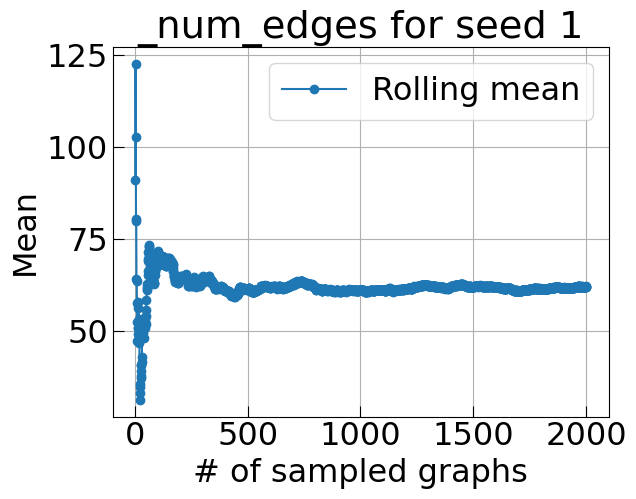

In [ ]:
fig, ax = plt.subplots()
x = np.arange(2, len(prog_mean) + 2)
ax.plot(
    x,
    prog_mean,
    '-o',
    label='Rolling mean'
)
ax.set(
    xlabel="# of sampled graphs",
    ylabel="Mean",
    title=f"{net_meas} for vsplit {vsplit}",
)
ax.grid(True)
ax.legend()
plt.show()

## Miscellanea

Fit `delta` with `L_Intra` num edges

In [ ]:
x0 = [1.8996372e-17]
model.load_or_fit(x0 = x0[0], maxiter = 30, verbose = 2)
# print(f'-utils.signed_rel_err(model._exp_num_edges, g._num_edges): {utils.signed_rel_err(model.expected_num_edges(), g._num_edges)}',)

-Load the parameter enforcing num_edges_full -> param: [6.30534189e-15]


### Compute observed Page-Ranks on the splitted networks

In [ ]:
# from os.path import dirname as up

# gI_dirfunc = lambda intra_size, vsplit: up(up(g.vars_dir)) + f"/intra_size{intra_size}/vsplit{vsplit}/level{g.level}"

# for intra_size in intra_sizes:
# 	for vsplit in range(num_vsplits):
        
# 		# vsplit nodes, edges in interal
# 		if not os.path.exists(gI_dirfunc(intra_size, vsplit)):
# 			vI, eI = g.vsplit_intra_row(v, e, intra_size=intra_size, vsplit=vsplit)

# 			# update the graph name
# 			kwargs_graph.update({'graph_kind': "intra", "intra_size" : intra_size, "vsplit" : vsplit})
# 			gI = sp.graphs.DiGraph(vI, eI, **kwargs_graph)

# 			# compute the page-rank only in the internal part
# 			gI._page_rank = gI.pagerank_power(**g._kwargs_pr)

# 			gI.save_vars()
            
# plot.pagerank_on_internal_nodes(g, gI_dirfunc, intra_size, num_vsplits,)

Filter them, retaining only Intra Nodes

In [ ]:
# g.in_strength()
# g.out_strength()
# gI._in_strength = g._in_strength[idx_IntraNode2Full]
# gI._out_strength = g._out_strength[idx_IntraNode2Full]

### Sampling with GPUs in Torch or CPUs with numba

In [ ]:
# Sampled torch GPU vs numba on CPU
# unsampled_vI = np.zeros(model.num_vertices, dtype=np.bool_)
# param, prop_out, prop_in, unsampled_vI = prop_to_torch(model, unsampled_vI)

# a = model.tc_block_parallel_sample(
#                 model.tc_p_ij,
#                 param,
#                 prop_out,
#                 prop_in,
#                 model.tc_prop_dyad,
#                 model.selfloops,
#                 unsampled_vI,
#                 chunk_row_size=200
#             )

# from graph_ensembles.sparse import DiGraphEnsemble
# unsampled_vI = np.zeros(model.num_vertices, dtype=np.bool_)
# a = DiGraphEnsemble.block_parallel_sample(
#                 model.p_ij,
#                 model.param,
#                 model.prop_out,
#                 model.prop_in,
#                 model.prop_dyad,
#                 model.selfloops,
#                 unsampled_vI,
#             )

### PyTorch row and col blocks (it is really slower than with only one for-loop)

In [ ]:
def block_parallel_sample_tc_optimized(param, prop_out, prop_in, selfloops, unsampled_vI, chunk_row_size=1000, chunk_col_size=1000, seed=0):
    """
    Efficiently sample edges in smaller blocks (row and column chunks)
    to avoid GPU memory overflow.
    """
    N = prop_out.shape[0]
    device = prop_out.device

    # Seed once at the beginning
    if device.type == 'cuda':
        tc.cuda.manual_seed(seed)
    else:
        tc.manual_seed(seed)

    all_rows_gpu = []
    all_cols_gpu = []

    # Iterate over chunks of rows
    for start_i in range(0, N, chunk_row_size):
        end_i = min(start_i + chunk_row_size, N)
        idx_i_chunk = tc.arange(start_i, end_i, device=device)
        # current_chunk_rows = idx_i_chunk.shape[0]

        # Iterate over chunks of columns
        for start_j in range(0, N, chunk_col_size):
            end_j = min(start_j + chunk_col_size, N)
            idx_j_chunk = tc.arange(start_j, end_j, device=device)
            # current_chunk_cols = idx_j_chunk.shape[0]

            # Create meshgrid for the current block only
            grid_i_block, grid_j_block = tc.meshgrid(idx_i_chunk, idx_j_chunk, indexing='ij')
            grid_i_block = grid_i_block.flatten()
            grid_j_block = grid_j_block.flatten()

            # Mask some pairs within the block
            mask = tc.ones_like(grid_i_block, dtype=tc.bool)

            if not selfloops:
                mask &= (grid_i_block != grid_j_block)

            if unsampled_vI.any():
                mask &= ~(unsampled_vI[grid_i_block] & unsampled_vI[grid_j_block])

            grid_i_sampled = grid_i_block[mask]
            grid_j_sampled = grid_j_block[mask]

            # Compute probabilities over the unmasked pairs in this block
            if grid_i_sampled.numel() > 0: # Only proceed if there are pairs to sample
                x_i_sampled = prop_out[grid_i_sampled]
                y_j_sampled = prop_in[grid_j_sampled]

                # Assuming tc_prop_dyad can handle tensors of indices
                # If tc_prop_dyad needs specific (i, j) for *each* pair, it needs adjustment.
                # For this example, assuming it works with a single dummy value or can be vectorized.
                z_ij_sampled = tc_prop_dyad(grid_i_sampled, grid_j_sampled) # Potentially problematic if not vectorized

                p = tc_p_ij(param, x_i_sampled, y_j_sampled, z_ij_sampled)

                # Sample edges
                rand = tc.rand_like(p)
                selected_idx = tc.where(rand < p)

                all_rows_gpu.append(grid_i_sampled[selected_idx])
                all_cols_gpu.append(grid_j_sampled[selected_idx])

    # Concatenate all results on the GPU, then transfer to CPU once
    if all_rows_gpu:
        rows_gpu = tc.cat(all_rows_gpu)
        cols_gpu = tc.cat(all_cols_gpu)
        rows = rows_gpu.cpu().numpy()
        cols = cols_gpu.cpu().numpy()
    else:
        rows = tc.empty(0, dtype=tc.int64).numpy()
        cols = tc.empty(0, dtype=tc.int64).numpy()

    return rows, cols

Check the average with W's method is the same of np.mean

In [ ]:
ens_max_idx = 99
num_samples = ens_max_idx + 1
ensemble_net_meas = np.empty(shape = num_samples)
net_meas = "_num_edges"

# more stable than np.mean
ens_avg_num_edges = 0
for i in range(ens_max_idx + 1):
    gi_num_edges = utils.load_dict(model.vars_dir_ensembles + f"/graph{i}/graph{i}.pkl")[net_meas]
    num_ens_graphs = i + 1
    delta = gi_num_edges - ens_avg_num_edges
    ens_avg_num_edges += delta / num_ens_graphs

# np.mean returns a differen value
for i in range(ens_max_idx + 1):
    graph_net_meas = utils.load_dict(model.vars_dir_ensembles + f"/graph{i}/graph{i}.pkl")[net_meas]
    ensemble_net_meas[i] = graph_net_meas
ens_mean = np.mean(ensemble_net_meas)

print(f'-ens_avg_num_edges - ens_mean: {ens_avg_num_edges - ens_mean}',)

-ens_avg_num_edges - ens_mean: -3.637978807091713e-12


Check if `unsampled_vI` entries are fixed

In [ ]:
import numpy as np
from itertools import product

# select the unsampled_vI
uns_id = np.where(unsampled_vI)[0]

# create a mapping from node to id
matidx_2_id = {k:v for k,v in enumerate(uns_id)}

# create a meshgrid
rows, cols = np.array(list(product(uns_id, repeat=2))).T
uns_N = len(uns_id)
print(f'-uns_N: {uns_N}',)

# filter the gs.adj for all the uns_id pairs
mat = gs.adj[rows, cols].reshape(uns_N, uns_N)

# find where mat is true
mat_rows, mat_cols = np.where(mat)

# create the DataFrame mapped into full-id nodes
frozen_edges_mat = pd.DataFrame({"_src" : mat_rows, "_dst" : mat_cols}).map(matidx_2_id.get)

# check the edges are the same
frozen_edges_mat.eq(frozen_edges).all()

-uns_N: 15


np.True_

Do Page-Rank for `gU`

In [ ]:
# find idx of edges containing v and filter edges
idx_at_least_one_ = lambda vI: e['src'].isin(vI['id']) | e['dst'].isin(vI['id'])

# containing vI, vR
idx_eU = idx_at_least_one_(vI)

# select the edge ING
eU = 3
# eU = edge_idx(idx_eU)

# reselect vU, since using v leads to inactive nodes not well-handled by the DiGraph
vU = unique_nodes_from(eU.iloc[:,:2])

In [ ]:
# kwargs_graph.update({'intra_size' : intra_size, 'vsplit' : vsplit, 'graph_kind' : "intra_inter",})
gU = sp.graphs.DiGraph(vU, eU, **kwargs_graph)
# g.load_or_create_degrees()

Compare the United PageRank vs Full PageRank over all the `vU` 

In [ ]:
pr_gU = pagerank_power(gU.adj, p=0.85, max_iter=100,
                   tol=1e-06, personalize=None, reverse=True)

In [ ]:
idx_IntraNode2United = list(map(lambda x: gU.id_dict.get(x), gI.id_dict))
pr_gU_on_Intra = pr_gU[idx_IntraNode2United]

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([pr_g_on_I.min(), pr_g_on_I.max()],
        [pr_g_on_I.min(), pr_g_on_I.max()],
        'r--')

ms, alpha = 30, 0.6
ax.scatter(pr_g_on_I, pr_gI, alpha=alpha, label = f"Intra PR", marker = 'o', c = dep.obs_color, s = ms)
ax.scatter(pr_g_on_I, pr_gU_on_Intra, alpha=alpha, label = f"United PR", marker = 'x', c = dep.ref_model_color, s = ms)
ax.set(
    xlabel='Full-PR on Intra',
    ylabel='Intra/United',
    title='PageRank: Intra/United VS Full',
    xscale='log',
    yscale='log'
)
leg = ax.legend()
for lh in leg.legend_handles:
    lh.set_alpha(1)
    lh.set_sizes([60])
ax.grid(False)

utils.save_fig(fig, full_path = g.plots_base_dir + "/PageRanks_on_Intra.pdf")
plt.close()

[Text(0.5, 0, 'Full-PR on Intra'),
 Text(0, 0.5, 'Intra/United'),
 Text(0.5, 1.0, 'PageRank: Intra/United VS Full'),
 None,
 None]